In [110]:
import os
import random

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

In [111]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [112]:
DATASET_PATH = "/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages"

In [113]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [114]:
# from PIL import ImageFile
# ImageFile.LOAD_TRUNCATED_IMAGES = True

In [115]:
from PIL import Image
from torchvision.datasets import ImageFolder

class CleanImageFolder(ImageFolder):

    def __getitem__(self, index):

        while True:

            try:
                return super().__getitem__(index)

            except Exception:

                print(f"Skipping corrupted image: {self.samples[index][0]}")

                index = (index + 1) % len(self.samples)

In [116]:
dataset = CleanImageFolder(root=DATASET_PATH,transform=train_transform)

print(dataset.classes)
print(len(dataset))
print(dataset.class_to_idx)

['Cat', 'Dog']
25000
{'Cat': 0, 'Dog': 1}


In [117]:
train_size=int(0.8*len(dataset))

val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

Training Images: 20000
Validation Images: 5000


In [118]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)

val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

In [119]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


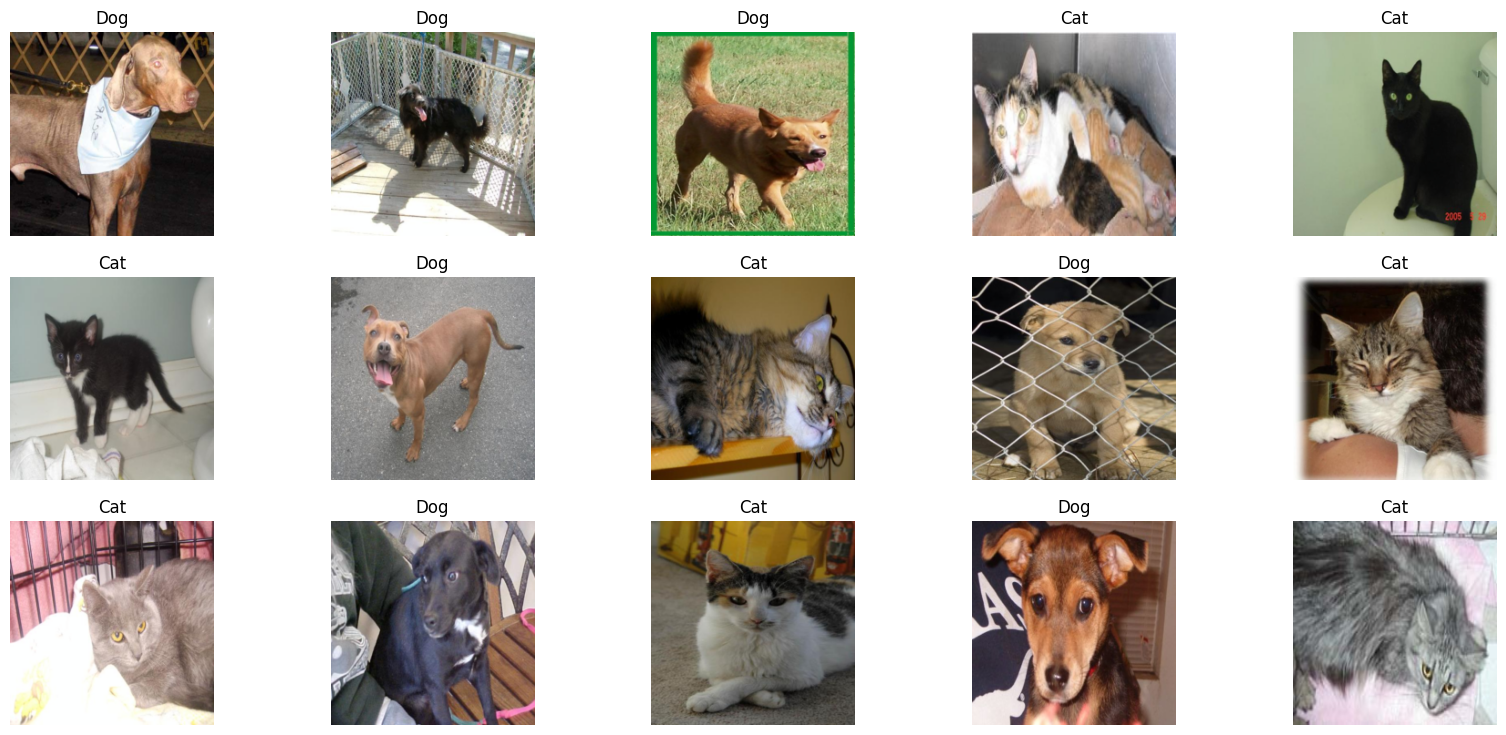

In [120]:
#visualizing 15 images together
fig, axes = plt.subplots(3,5, figsize=(20,9))
class_names = dataset.classes

for i, ax in enumerate(axes.flat):

    image = images[i]
    image = image.permute(1,2,0)
    image = image.numpy()
    image = image * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    image = np.clip(image,0,1)

    ax.imshow(image)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.show()

In [121]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

In [122]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [123]:
num_features=model.fc.in_features

model.fc=nn.Linear(num_features,2)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [124]:
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"

model = model.to(device)

print(device)

cuda


In [125]:
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)
print(outputs.shape)

torch.Size([32, 2])


In [126]:
from tqdm import tqdm

EPOCHS = 15

best_val_acc = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

optimizer=optim.Adam(model.parameters(),lr=0.0001)
criterion=nn.CrossEntropyLoss()


for epoch in range(EPOCHS):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss/len(train_loader)
    train_acc = 100 * (correct/total)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss/len(val_loader)
    val_acc = 100 * (correct/total)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.2f}%")


    if val_acc > best_val_acc:

        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Best Model Saved")

 59%|█████▉    | 368/625 [01:22<00:56,  4.57it/s]

Skipping corrupted image: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg


 69%|██████▉   | 432/625 [01:36<00:43,  4.48it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 625/625 [02:19<00:00,  4.47it/s]


Skipping corrupted image: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg
Epoch 1/15
Train Loss : 0.0666
Train Accuracy : 97.55%
Validation Loss : 0.0410
Validation Accuracy : 98.56%
Best Model Saved


 54%|█████▍    | 337/625 [01:17<01:11,  4.04it/s]

...

Skipping corrupted image: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg
Epoch 14/15
Train Loss : 0.0060
Train Accuracy : 99.80%
Validation Loss : 0.1000
Validation Accuracy : 96.98%


 46%|████▌     | 287/625 [01:04<01:23,  4.06it/s]

Skipping corrupted image: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg


100%|██████████| 625/625 [02:27<00:00,  4.25it/s]


Skipping corrupted image: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg
Epoch 15/15
Train Loss : 0.0053
Train Accuracy : 99.86%
Validation Loss : 0.0606
Validation Accuracy : 98.20%


In [127]:
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
model = resnet18(weights=None)

model.fc = nn.Linear(model.fc.in_features,2)
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [145]:
y_true=[]
y_pred=[]

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        labels=labels.to(device)

        outputs=model(images)

        predictions=torch.argmax(outputs,dim=1)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(predictions.cpu().numpy())

Skipping corrupted image: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg


In [146]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

accuracy=accuracy_score(y_true,y_pred)
cm=confusion_matrix(y_true,y_pred)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Confusion Matrix\n {cm}")

Accuracy : 98.98%
Confusion Matrix
 [[2499   14]
 [  37 2450]]


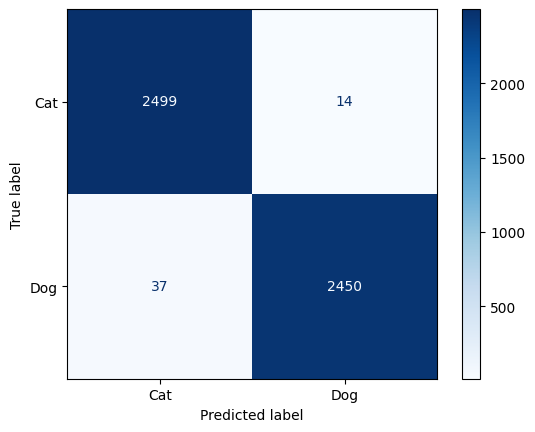

In [147]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Cat","Dog"])

disp.plot(cmap="Blues")
plt.show()

In [148]:
print(classification_report(y_true,y_pred,target_names=["Cats","Dogs"]))

              precision    recall  f1-score   support

        Cats       0.99      0.99      0.99      2513
        Dogs       0.99      0.99      0.99      2487

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



Test

In [149]:
class_names = ["Cat", "Dog"]

predict_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [150]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    image = predict_transform(image)

    image = image.unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():

        outputs = model(image)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probabilities, dim=1)

    print(f"Prediction : {class_names[predicted.item()]}")
    print(f"Confidence : {confidence.item()*100:.2f}%")

    return class_names[predicted.item()]

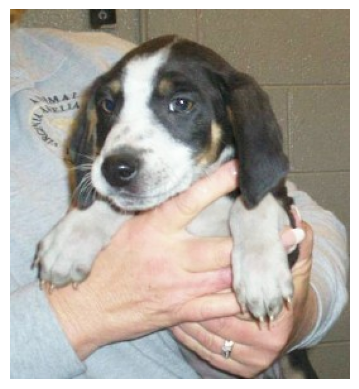

Prediction : Dog
Confidence : 100.00%


'Dog'

In [151]:
predict_image("/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/10.jpg")

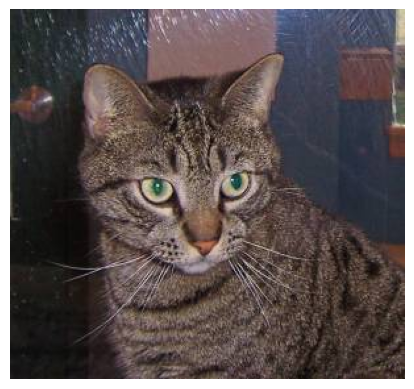

Prediction : Cat
Confidence : 100.00%


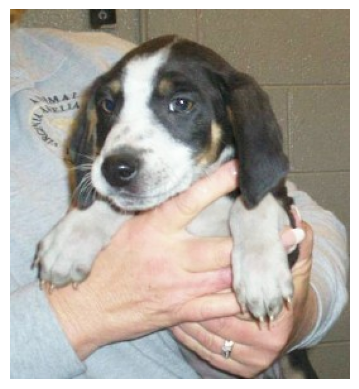

Prediction : Dog
Confidence : 100.00%


In [152]:
test_images = [
    "/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Cat/1.jpg",
    "/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/10.jpg"
]

for image in test_images:

    print("="*50)

    predict_image(image)

In [153]:
!pip install grad-cam -q

In [154]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import cv2
import numpy as np

In [155]:
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model,target_layers=target_layers)

In [156]:
image_path="/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/100.jpg"
image=Image.open(image_path).convert("RGB")

rgb=np.array(image)
rgb=cv2.resize(rgb,(224,224))
rgb=rgb.astype(np.float32)/255

In [157]:
input_tensor=predict_transform(image)
input_tensor=input_tensor.unsqueeze(0)
input_tensor=input_tensor.to(device)

In [158]:
targets=None
grayscale_cam=cam(input_tensor=input_tensor,targets=targets)

grayscale_cam=grayscale_cam[0]

visualization=show_cam_on_image(rgb,grayscale_cam,use_rgb=True)

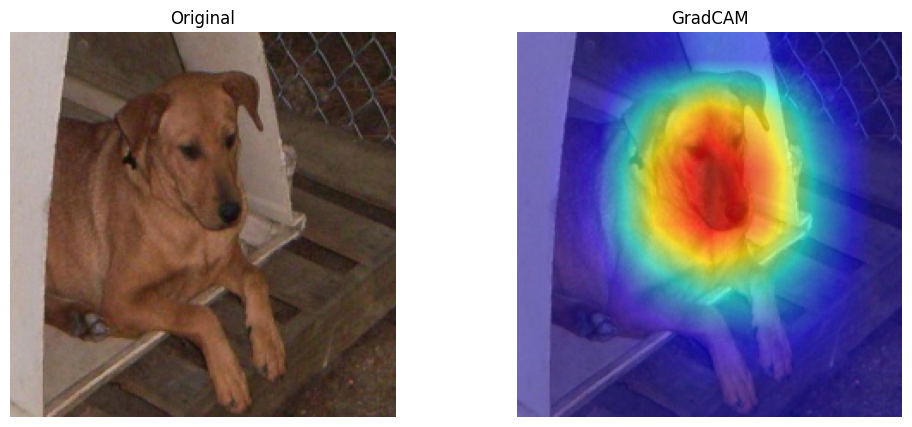

In [159]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("GradCAM")
plt.axis("off")

plt.show()